In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample_poly,decimate

def downsample_in_chunks(x,fs, step, chunk_size=7):
    """Integer decimation by `step`, processed in chunks, with correct global alignment."""
    y_parts = []
    global_start = 0
    up, down = 1, step
    print(up,down)
    for k0 in range(0, len(x), chunk_size):
        k1 = min(k0 + chunk_size, len(x))
        chunk = x[k0:k1]
        # L = len(chunk)
        # offset = (-global_start) % step      # 0..step-1
        # print(chunk)
        y_chunk = resample_poly(chunk, up, down, axis=0, window=('kaiser', 5.0), padtype='constant', cval=None)
        y_parts.append(y_chunk)
        # global_start += L

    return np.concatenate(y_parts) if y_parts else np.empty((0,), dtype=x.dtype)

# Demo & verification
N = 5300
step = 10
fs = 100
x = np.sin(np.arange(N)/100)#np.array(np.arange(N),dtype=np.float64)                    # stand-in for your signal
# y_ref = x[::step]                   # ground truth
# y_chunked = downsample_in_chunks(x, fs,step, chunk_size=100)

# print("match:", np.array_equal(y_chunked, y_ref))   # -> True
# print("y:", y_chunked)

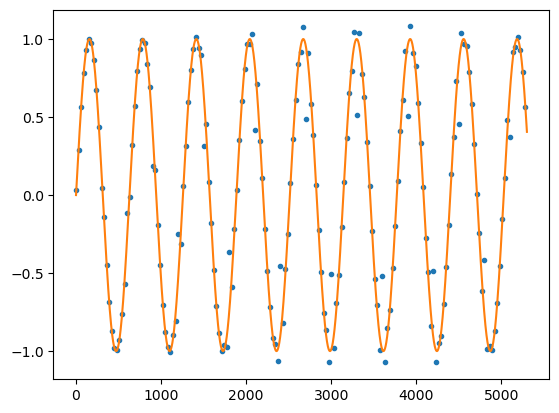

In [2]:

# plt.plot(np.arange(len(x)),x)
chunk_size = 300
down_sampled = []
down_sampled_normal = []

downsampling_ratio = 30
for k0 in range(0, len(x), chunk_size):
    k1 = min(k0 + chunk_size, len(x))
    chunk = x[k0:k1]
    # plt.plot(np.arange(k0,k1),chunk,'-')
    
    # down_sampled_chunk = decimate(chunk,downsampling_ratio , n=None, ftype='iir', axis=-1, zero_phase=True)
    down_sampled_chunk = resample_poly(chunk, 1, downsampling_ratio, axis=0, window=('kaiser', 10.0), padtype='constant', cval=None)
    down_sampled.extend(down_sampled_chunk)

    down_sampled_chunk = chunk[::downsampling_ratio]
    down_sampled_normal.extend(down_sampled_chunk)
    # plt.plot(np.arange(k0,k1,5),down_sampled_chunk,'.')

plt.plot(np.arange(0,len(down_sampled))*(downsampling_ratio),down_sampled,'.')
plt.plot(np.arange(0,len(x)),x)
# plt.plot(np.arange(0,len(down_sampled))*(downsampling_ratio),down_sampled_normal,'.k')
# plt.plot(np.arange(len(y_chunked))*(step),y_chunked,'-',alpha=0.5)

In [4]:
# !pip install soxr
import soxr

rs = soxr.ResampleStream(in_rate=44100, out_rate=16000, num_channels=1, dtype='float32')

while more_input:
    y_chunk = rs.resample_chunk(x_chunk, last=False)
    # Process y_chunk...
# At the end:
y_tail = rs.resample_chunk(np.array([]), last=True)

TypeError: __init__() got an unexpected keyword argument 'input_rate'

In [3]:
!pip install python-soxr

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement python-soxr (from versions: none)
ERROR: No matching distribution found for python-soxr


In [2]:
%matplotlib widget
import sys, importlib, os
import McsPy.McsData
import McsPy.McsCMOS
from McsPy import ureg, Q_

# matplotlib.pyplot will be used in these examples to generate the plots visualizing the data
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.widgets import Slider
import numpy as np
from scipy import signal
from scipy.ndimage import gaussian_filter1d

import seaborn as sns
# import datashader as ds
# import datashader.transfer_functions as tf
import pandas as pd

na = np.array
import scipy.signal
import matplotlib.pyplot as plt

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import h5py
import os 


In [ ]:
# Original file
# file_name = '/mnt/server_epl/SCN1A/R1648H-export/28-10-24/slice1/2024-10-28T11-30-32slice1.h5'
file_name ='/mnt/server_epl/SCN1A/R1648H-export/25-3-25/slice1/2025-03-25T11-07-24McsRecording.h5'
with h5py.File(file_name, "r") as f:
    data = f['Data']['Recording_0']['AnalogStream']['Stream_0']['ChannelData']
    data = na(data[0,:])
    # n_channels, n_samples_in = data.shape

In [ ]:
channel_raw_data = McsPy.McsData.RawData(file_name)    
analog_stream_0 = channel_raw_data.recordings[0].analog_streams[0]
adc_step = analog_stream_0.channel_infos[2].adc_step.magnitude 
fs = na(analog_stream_0.channel_infos[2].sampling_frequency) # get frequency

In [ ]:


# target_file = '../data/test/R1648H_28-10-24_slice1_2024-10-28T11-30-32slice1.h5_filtered_orig1.h5'# test file
target_file = '../data/test/R1648H_25-03-25_slice1_2025-03-25T11-07-24McsRecording.h5_filtered_orig1.h5'#readl recording with 
mv_scale_factor =  1000000
subsampling_rate =2000
with h5py.File(target_file, 'r') as f:
    # print(f.keys())
    # print(f['data'].shape)
    filt=f['data'][0,:]
    # subsampling_rate = f['resampled_rate']
    # subsampling_rate = na(f['/resampled_rate'])
    adc_step = na(f['scale'])
print(subsampling_rate)
subsampling_rate = subsampling_rate
print('subsampling_rate',subsampling_rate)

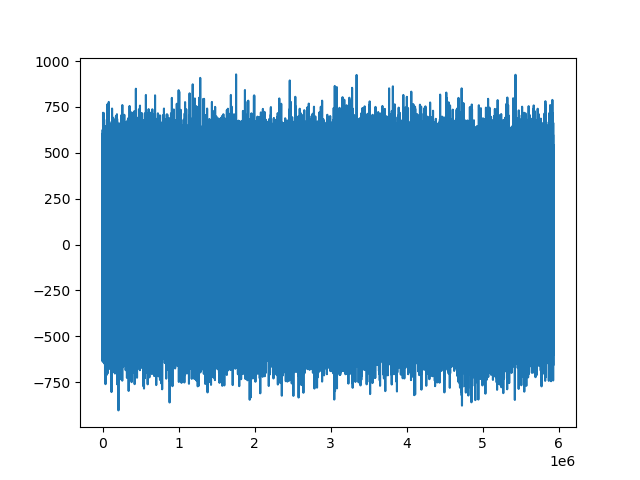

In [147]:
plt.figure()
plt.plot(data)

In [81]:
data.shape

(5932000,)

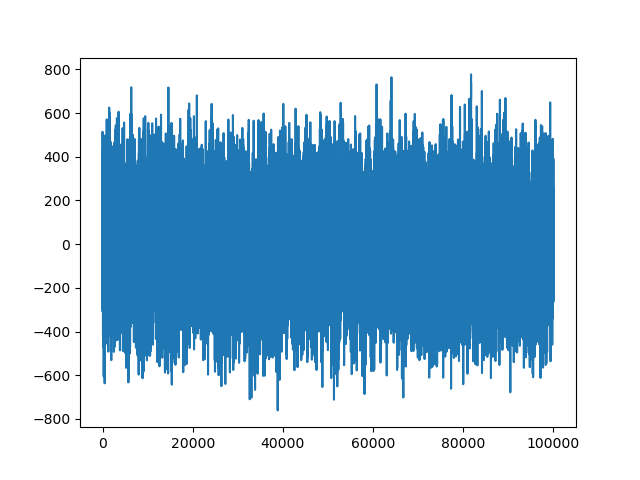

In [22]:
plt.figure()
plt.plot(data[0,:])

In [35]:
data.shape

(10, 100000)

In [55]:
100000*10

1000000

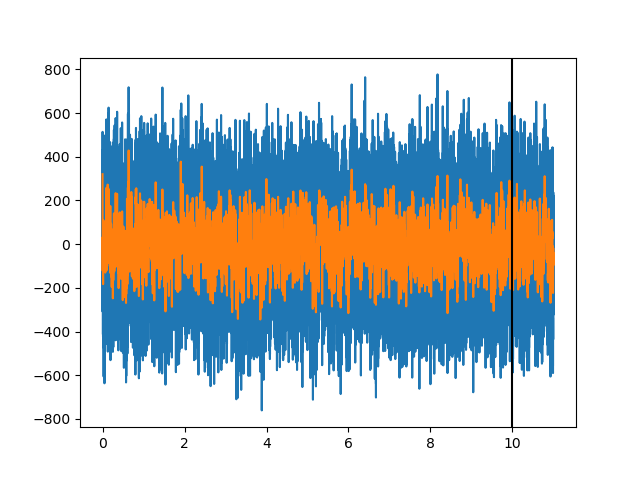

In [148]:
plt.figure()
# plt.figure()
plt.plot(np.arange(0,110000)*(1/10000),data[:110000])
plt.plot(np.arange(0,22000)*(1/2000),filt[:22000,0],'-')
plt.axvline(10,color='k')

In [138]:
np.unique(data)

array([-904, -878, -861, ...,  924,  925,  927], dtype=int32)

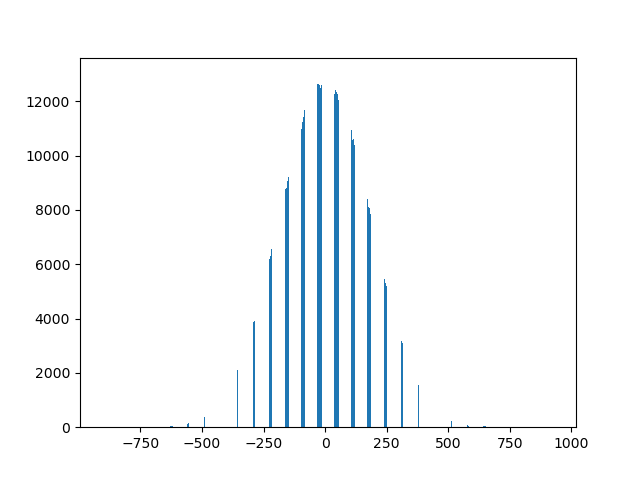

In [132]:
plt.figure()
plt.hist(data,10000);

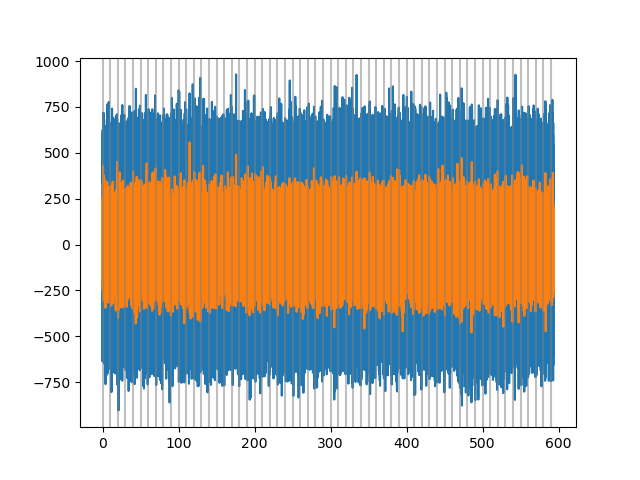

In [160]:
plt.figure()
# plt.figure()
plt.plot(np.arange(0,len(data))*(1/10000),data[:],'-')
plt.plot(np.arange(0,len(filt))*(1/2000),filt[:,0],'-')
[plt.axvline(k,color='gray',alpha=0.5) for k in  np.arange(0,len(data)*(1/10000),10)];

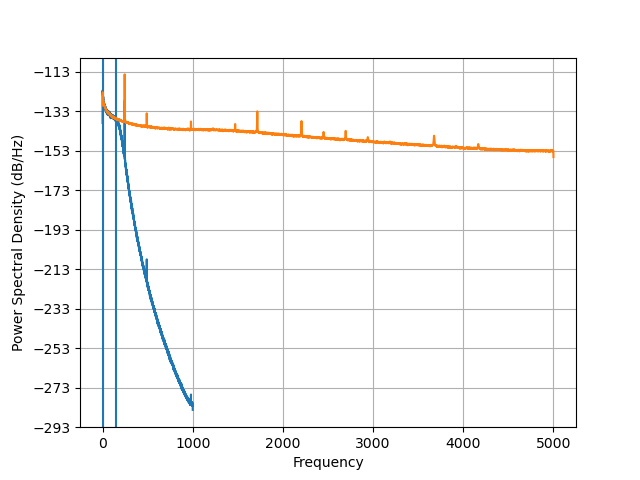

In [162]:
plt.figure()
plt.psd(filt[:,0]*adc_step,Fs=2000,NFFT=100**2);
plt.axvline(150)
plt.axvline(1)
plt.psd(data*adc_step,Fs=10000,NFFT=100**2);

In [ ]:
with h5py.File(file_name, "r") as f_in, h5py.File(target_file, "a") as f_out:
    data = f_in['Data']['Recording_0']['AnalogStream']['Stream_0']['ChannelData']
    dset = f_out['data']

In [38]:
len(filt[0])

494334

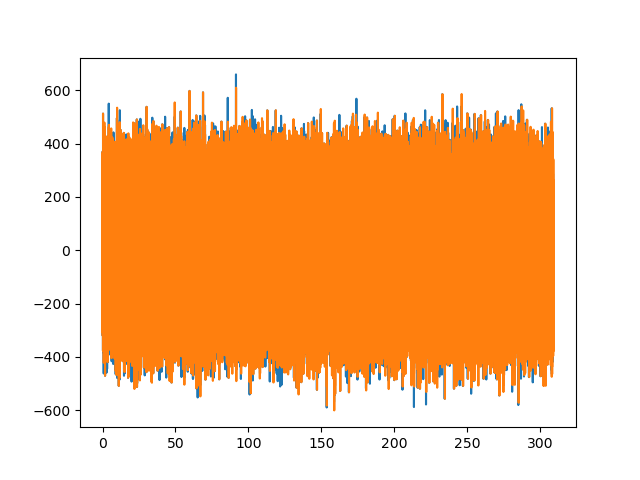

In [42]:
plt.figure()
n_max=494334
plt.plot(np.arange(0,len(filt[0][:,0]))*(1/subsampling_rate),filt[0][:,0])
plt.plot(np.arange(0,len(filt[1][:,0]))*(1/subsampling_rate),filt[1][:,0],'-')
# plt.plot(np.arange(0,n_max)*(1/fs),data[0,0:n_max],'-k',alpha=0.2)